## CELL: 01 Load Prices

In [4]:
import duckdb, numpy as np, pandas as pd, ruptures as rpt
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
db_path = ROOT / "data" / "openag.duckdb"

con = duckdb.connect(str(db_path), read_only=True)
prices = con.sql('SELECT "Date", "Close" FROM prices ORDER BY "Date"').df()
con.close()

prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.set_index("Date")
prices["Close"] = pd.to_numeric(prices["Close"], errors="coerce")
prices = prices.dropna(subset=["Close"])
print(prices.shape, prices.index.min().date(), "→", prices.index.max().date())

(2512, 1) 2016-06-06 → 2026-06-05


## Cell 2 — log returns + rolling realized vol

In [5]:
prices["log_ret"] = np.log(prices["Close"]).diff()
prices["rolling_vol"] = prices["log_ret"].rolling(21).std() * np.sqrt(252)  # ~1-month, annualized
ret = prices["log_ret"].dropna()
logp = np.log(prices["Close"])

## Cell 3 — dual PELT across a penalty sweep

In [6]:
def sweep(signal, model, pens, min_size=20):
    algo = rpt.Pelt(model=model, min_size=min_size).fit(signal.reshape(-1, 1))
    out = {pen: algo.predict(pen=pen) for pen in pens}
    return {pen: len(bk) - 1 for pen, bk in out.items()}, algo  # -1: drop terminal index

pens = [5, 10, 20, 40, 80, 160, 320]
var_counts,   var_algo   = sweep(ret.values,  "normal", pens)  # variance-flavored (top panel breaks)
trend_counts, trend_algo = sweep(logp.values, "l2",     pens)  # level/trend-flavored (middle panel breaks)
print("variance:", var_counts)
print("trend:   ", trend_counts)

c:\Users\siddh\Downloads\OPEN-AG\openag-risk-twin\.venv\Lib\site-packages\ruptures\costs\costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


variance: {5: 51, 10: 22, 20: 13, 40: 6, 80: 4, 160: 0, 320: 0}
trend:    {5: 2, 10: 2, 20: 2, 40: 2, 80: 0, 160: 0, 320: 0}


## Cell 4 — pick a plateau penalty, map to dates, overlay on price vs anchors

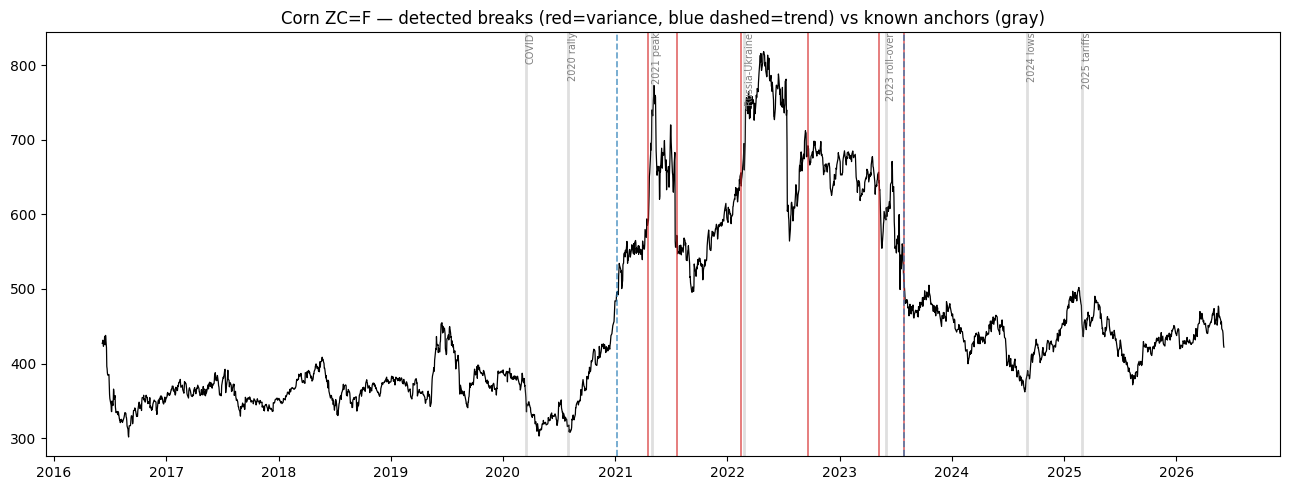

In [7]:
PEN_VAR, PEN_TREND = 40, 40  # ← adjust to the plateau you see in Cell 3

var_bk   = var_algo.predict(pen=PEN_VAR)[:-1]    # drop terminal index
trend_bk = trend_algo.predict(pen=PEN_TREND)[:-1]
var_dates   = ret.index[[i - 1 for i in var_bk]]   # ret is diff()-shifted by 1
trend_dates = logp.index[trend_bk]

anchors = {"COVID":"2020-03-15","2020 rally":"2020-08-01","2021 peak":"2021-05-01",
           "Russia-Ukraine":"2022-02-24","2023 roll-over":"2023-06-01",
           "2024 lows":"2024-09-01","2025 tariffs":"2025-03-01"}

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(prices.index, prices["Close"], lw=.9, color="black")
for d in var_dates:   ax.axvline(d, color="tab:red",  lw=1.2, alpha=.7)
for d in trend_dates: ax.axvline(d, color="tab:blue", lw=1.2, alpha=.7, ls="--")
for label, d in anchors.items():
    ax.axvline(pd.Timestamp(d), color="gray", lw=2, alpha=.25)
    ax.text(pd.Timestamp(d), ax.get_ylim()[1], label, rotation=90, va="top", fontsize=7, color="gray")
ax.set_title("Corn ZC=F — detected breaks (red=variance, blue dashed=trend) vs known anchors (gray)")
plt.tight_layout(); plt.show()

## Cell 5 — confirm each break with the test appropriate to its kind

In [8]:
from scipy import stats

def chow_mean_break(series, break_date, window_days=400):
    """Chow test for a level/mean break (intercept-only model, k=1)."""
    seg = series.loc[break_date - pd.Timedelta(days=window_days):
                     break_date + pd.Timedelta(days=window_days)].dropna()
    left, right = seg.loc[:break_date], seg.loc[break_date:]
    n1, n2 = len(left), len(right)
    if min(n1, n2) < 20:
        return None
    rss_p = ((seg   - seg.mean())  ** 2).sum()
    rss_1 = ((left  - left.mean()) ** 2).sum()
    rss_2 = ((right - right.mean())** 2).sum()
    F = (rss_p - (rss_1 + rss_2)) / ((rss_1 + rss_2) / (n1 + n2 - 2))
    return F, stats.f.sf(F, 1, n1 + n2 - 2), left.mean(), right.mean()

def var_break(returns, break_date, window_days=250):
    """Two-sided F-test for a variance (volatility) break."""
    seg = returns.loc[break_date - pd.Timedelta(days=window_days):
                      break_date + pd.Timedelta(days=window_days)].dropna()
    left, right = seg.loc[:break_date], seg.loc[break_date:]
    n1, n2 = len(left), len(right)
    if min(n1, n2) < 20:
        return None
    v1, v2 = left.var(ddof=1), right.var(ddof=1)
    F = max(v1, v2) / min(v1, v2)
    dfn, dfd = (n1 - 1, n2 - 1) if v1 >= v2 else (n2 - 1, n1 - 1)
    p = 2 * stats.f.sf(F, dfn, dfd)
    return F, p, np.sqrt(v1 * 252), np.sqrt(v2 * 252)

print("TREND breaks — Chow test on price level:")
for d in trend_dates:
    r = chow_mean_break(prices["Close"], d)
    if r: F, p, m1, m2 = r; print(f"  {d.date()}:  F={F:8.1f}  p={p:.2e}   mean {m1:.0f} → {m2:.0f} ¢")

print("\nVARIANCE breaks — F-test on return variance:")
for d in var_dates:
    r = var_break(prices["log_ret"], d)
    if r: F, p, s1, s2 = r; print(f"  {d.date()}:  F={F:6.2f}  p={p:.2e}   vol {s1:.0%} → {s2:.0%}")

TREND breaks — Chow test on price level:
  2021-01-05:  F=  2582.7  p=2.50e-210   mean 365 → 586 ¢
  2023-07-31:  F=  3370.9  p=1.67e-236   mean 646 → 445 ¢

VARIANCE breaks — F-test on return variance:
  2021-04-16:  F=  2.91  p=7.20e-12   vol 24% → 40%
  2021-07-20:  F=  2.46  p=7.15e-09   vol 42% → 27%
  2022-02-14:  F=  1.03  p=8.51e-01   vol 36% → 35%
  2022-09-20:  F=  3.47  p=2.88e-15   vol 36% → 19%
  2023-05-10:  F=  4.55  p=2.83e-21   vol 18% → 38%
  2023-07-31:  F=  3.14  p=3.11e-13   vol 36% → 21%


## Cell 6 — WASDE parse + as-of join onto the trading calendar

In [11]:
# date keys to a single resolution
def to_ns(s): return pd.to_datetime(s).astype("datetime64[ns]")

# --- WASDE: exact attribute, US, inspect what splits the rows ---
es_src = wasde_raw[
    wasde_raw["Commodity"].astype(str).str.contains("corn", case=False, na=False)
    & wasde_raw["Attribute"].astype(str).str.strip().eq("Ending Stocks")
    & wasde_raw["Region"].astype(str).str.contains("United States", case=False, na=False)
].copy()

print("ProjEstFlag      :", es_src["ProjEstFlag"].astype(str).unique())
print("AnnualQuarterFlag:", es_src["AnnualQuarterFlag"].astype(str).unique())
latest = es_src["ReportDate"].max()
print(f"\ncandidate rows for {latest.date()}:")
print(es_src[es_src["ReportDate"].eq(latest)]
      [["MarketYear","ProjEstFlag","AnnualQuarterFlag","Value"]].to_string(index=False))

es = es_src.copy()
es = es[es["AnnualQuarterFlag"].astype(str).str.contains("Annual", case=False, na=False)]
es = es[es["MarketYear"].astype(str).str.contains("/")]          # drop the NaN-marketing-year aggregate row
es["Value"] = pd.to_numeric(es["Value"], errors="coerce")
es = (es.sort_values(["ReportDate", "MarketYear"])               # "YYYY/YY" sorts chronologically
        .groupby("ReportDate", as_index=False).last()            # newest crop year = forward projection
        [["ReportDate", "Value"]]
        .rename(columns={"Value": "corn_ending_stocks_mmt"})
        .sort_values("ReportDate"))
es["ReportDate"] = to_ns(es["ReportDate"])
print(es.tail(4))   # 2026-05 should now read 49.71 (2026/27 proj, MMT)

# --- CFTC / drought / macro ---
cftc = cftc_raw.copy()
cftc["report_date"] = to_ns(cftc["report_date"])
cftc["spec_net"]        = cftc["noncomm_long"] - cftc["noncomm_short"]
cftc["spec_net_pct_oi"] = cftc["spec_net"] / cftc["open_interest"]
cftc = cftc.sort_values("report_date")[["report_date","spec_net","spec_net_pct_oi"]]

dr = drought_raw.copy()
dr["mapDate"] = to_ns(dr["mapDate"])
dr["drought_stress"] = pd.to_numeric(dr.get("d2"), errors="coerce")
dr = dr.sort_values("mapDate")[["mapDate","drought_stress"]]

mac = macro_raw.copy()
mac["date"] = to_ns(mac["date"])
mac = mac.sort_values("date")

# --- as-of join onto the trading calendar ---
panel = prices.reset_index()[["Date","Close","log_ret","rolling_vol"]].copy()
panel["Date"] = to_ns(panel["Date"])
panel = panel.sort_values("Date")
panel = pd.merge_asof(panel, cftc, left_on="Date", right_on="report_date", direction="backward")
panel = pd.merge_asof(panel, dr,   left_on="Date", right_on="mapDate",     direction="backward")
panel = pd.merge_asof(panel, mac,  left_on="Date", right_on="date",        direction="backward")
panel = pd.merge_asof(panel, es,   left_on="Date", right_on="ReportDate",  direction="backward")
panel = panel.set_index("Date").drop(columns=["report_date","mapDate","date","ReportDate"], errors="ignore")

print("\npanel:", panel.shape)
print("\nfirst valid date per feature:"); print(panel.apply(lambda s: s.first_valid_index()).sort_values())

ProjEstFlag      : <StringArray>
[nan, 'Est.', 'Proj.']
Length: 3, dtype: str
AnnualQuarterFlag: <StringArray>
['Annual']
Length: 1, dtype: str

candidate rows for 2026-05-01:
MarketYear ProjEstFlag AnnualQuarterFlag  Value
       NaN         NaN            Annual  18.00
   2024/25         NaN            Annual  39.40
   2025/26        Est.            Annual  54.41
   2026/27       Proj.            Annual  49.71
   ReportDate  corn_ending_stocks_mmt
60 2026-02-01                   54.02
61 2026-03-01                   54.02
62 2026-04-01                   54.02
63 2026-05-01                   49.71

panel: (2512, 10)

first valid date per feature:
Close                    2016-06-06
drought_stress           2016-06-06
usd_broad                2016-06-06
treasury_10y             2016-06-06
wti_crude                2016-06-06
log_ret                  2016-06-07
rolling_vol              2016-07-06
corn_ending_stocks_mmt   2021-01-04
spec_net                 2021-01-05
spec_net_pct_oi     

## Cell 7 — profile each regime across all five sources

In [12]:
breaks = pd.to_datetime([
    "2021-01-05",  # trend wall ↑
    "2021-04-16",  # vol ↑
    "2021-07-20",  # vol ↓
    "2022-09-20",  # vol ↓
    "2023-05-10",  # vol ↑
    "2023-07-31",  # trend wall ↓ + vol ↓
])
labels = ["calm_16_21", "breakout_21", "burst_spr21", "high_21_22",
          "cooling_22_23", "burst_spr23", "low_23_26"]

codes = np.searchsorted(breaks.values, panel.index.values, side="right")
panel["regime"] = pd.Categorical.from_codes(codes, categories=labels, ordered=True)

g = panel.groupby("regime", observed=True)
prof = g.agg(
    days        =("Close", "size"),
    px_mean     =("Close", "mean"),
    vol_mean    =("rolling_vol", "mean"),
    spec_pct_oi =("spec_net_pct_oi", "mean"),
    drought     =("drought_stress", "mean"),
    usd         =("usd_broad", "mean"),
    stocks_mmt  =("corn_ending_stocks_mmt", "mean"),
)
prof.insert(0, "start", g.apply(lambda d: d.index.min().date(), include_groups=False))
prof.insert(1, "end",   g.apply(lambda d: d.index.max().date(), include_groups=False))

prof["vol_mean"]    = (prof["vol_mean"] * 100).round(1)      # %
prof["spec_pct_oi"] = (prof["spec_pct_oi"] * 100).round(1)   # % of OI
prof = prof.round({"px_mean": 0, "drought": 1, "usd": 1, "stocks_mmt": 1})
print(prof.to_string())

                    start         end  days  px_mean  vol_mean  spec_pct_oi  drought    usd  stocks_mmt
regime                                                                                                 
calm_16_21     2016-06-06  2021-01-04  1150    366.0      20.9          NaN      3.1  114.5        39.4
breakout_21    2021-01-05  2021-04-15    70    546.0      26.1         28.5     12.3  112.5        37.9
burst_spr21    2021-04-16  2021-07-19    65    672.0      44.1         26.1     19.0  111.8        36.0
high_21_22     2021-07-20  2022-09-19   295    645.0      31.0         25.0      8.4  117.2        36.3
cooling_22_23  2022-09-20  2023-05-09   160    662.0      17.2         15.9     24.5  122.3        33.0
burst_spr23    2023-05-10  2023-07-28    55    587.0      43.0          1.4     20.3  119.0        57.1
low_23_26      2023-07-31  2026-06-05   717    440.0      20.9         -0.1     15.7  122.0        50.8


## Cell 8 — regime structure figure

saved → c:\Users\siddh\Downloads\OPEN-AG\openag-risk-twin\notebooks\figures\01_regime_structure.png


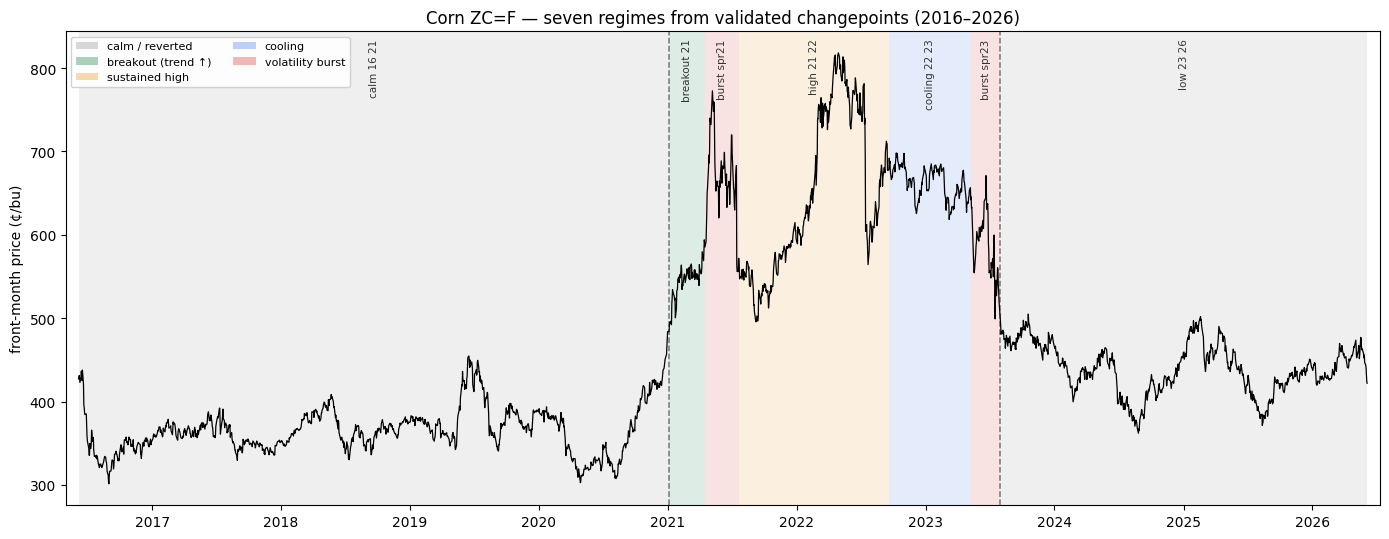

In [13]:
from matplotlib.patches import Patch

FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

regime_colors = {
    "calm_16_21":    "#9e9e9e",  # calm
    "breakout_21":   "#2e8b57",  # trend up
    "burst_spr21":   "#d9534f",  # vol burst
    "high_21_22":    "#e8a33d",  # sustained high
    "cooling_22_23": "#5b8def",  # cooling
    "burst_spr23":   "#d9534f",  # vol burst (same as spr21 — that's the point)
    "low_23_26":     "#9e9e9e",  # reverted calm
}
edges = [panel.index.min()] + list(breaks) + [panel.index.max()]

fig, ax = plt.subplots(figsize=(14, 5.5))
for i, lab in enumerate(labels):
    ax.axvspan(edges[i], edges[i + 1], color=regime_colors[lab], alpha=0.16, lw=0)
ax.plot(panel.index, panel["Close"], color="black", lw=0.9, zorder=3)

ylim = ax.get_ylim()
for i, lab in enumerate(labels):
    mid = edges[i] + (edges[i + 1] - edges[i]) / 2
    ax.text(mid, ylim[1] * 0.99, lab.replace("_", " "),
            rotation=90, va="top", ha="center", fontsize=7.5, color="#333")

for d in [pd.Timestamp("2021-01-05"), pd.Timestamp("2023-07-31")]:   # the two trend walls
    ax.axvline(d, color="black", lw=1.1, ls="--", alpha=0.5, zorder=2)

ax.set_title("Corn ZC=F — seven regimes from validated changepoints (2016–2026)", fontsize=12)
ax.set_ylabel("front-month price (¢/bu)")
ax.margins(x=0.01)
ax.legend(handles=[
    Patch(facecolor="#9e9e9e", alpha=0.4, label="calm / reverted"),
    Patch(facecolor="#2e8b57", alpha=0.4, label="breakout (trend ↑)"),
    Patch(facecolor="#e8a33d", alpha=0.4, label="sustained high"),
    Patch(facecolor="#5b8def", alpha=0.4, label="cooling"),
    Patch(facecolor="#d9534f", alpha=0.4, label="volatility burst"),
], loc="upper left", fontsize=8, framealpha=0.9, ncol=2)

plt.tight_layout()
out = FIG_DIR / "01_regime_structure.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("saved →", out)
plt.show()